### The missing piece of the model: Non-Linearity

'What patterns could you draw if you were given an infinite amount of a straight and non-straight lines?'

or in machine learning terms, an infinite (but really it is finite) Linear and non-linear functions.


### Recreating non-linear data (red and blue circles)



Matplotlib is building the font cache; this may take a moment.


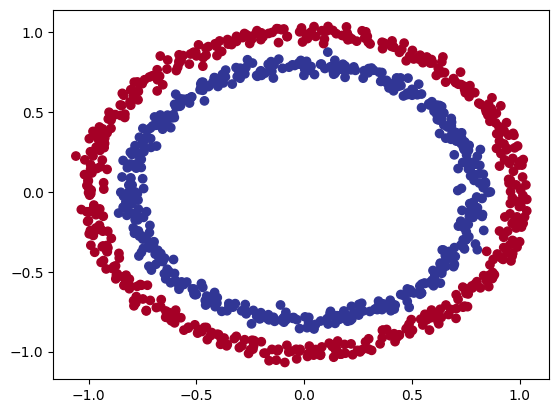

In [1]:
# Make and plot data
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
import numpy as np

n_samples = 1000

X, y = make_circles(n_samples, 
                    noise = 0.03,
                    random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu);

In [2]:
# Convert data to tensors and then to train and test splits
import torch 
from sklearn.model_selection import train_test_split

# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.2,
                                                     random_state=42)

device = "cuda" if torch.cuda.is_available() else "cpu"
X_train[:5], y_train[:5]



(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

In [3]:
### Useful functions 

# Calculate Accuracy - what percentage of the test data did the model predict right? 
# Accuracy = True positive/(True Positive + True Negative) * 100

def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct/len(y_pred)) * 100
    return acc



def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor): 
    
    # Put everything to cpu
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup decision boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101),
                         np.linspace(y_min, y_max, 101))
    
    # Make features 
    X_to_predict_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make Predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_predict_on)
        
        # Test for Multi_class or binary classifications and adjust logits to prediction labels
        if len(torch.unique(y)) > 2:
            y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # Multi-class
        else:
            y_pred = torch.round(torch.sigmoid(y_logits))  # Binary 
        
        # Reshape preds and plot
        y_pred = y_pred.reshape(xx.shape).detach().numpy()
        plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha = 0.7)
        plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap= plt.cm.RdYlBu)
        plt.xlim(xx.min(), xx.max())
        plt.ylim(yy.min(), yy.max())

# Building a model with non_linearity 

* Linear =  straight line 
* Non-linear = non-straight lines 

Artificial neural networks are a large combination of linear (straight) and non-straight (non-linear) functions which are potentially able to find patterns in data.

In [4]:
# Build a model with non-linear activation function
from torch import nn
class CircleModelV2(nn.Module):
    def __init__(self):
        super(). __init__()
        self.layer_1 = nn.Linear(in_features = 2, out_features = 10)
        self.layer_2 = nn.Linear(in_features = 10, out_features = 10)
        self.layer_3 = nn.Linear(in_features = 10, out_features = 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = CircleModelV2().to(device)

In [5]:
loss_fn = nn.BCEWithLogitsLoss()
optimiser = torch.optim.SGD(params = model_3.parameters(),
                            lr = 0.01)


In [6]:
# Setting random seeds 
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Put all data on target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

In [7]:
### Training The Model
epochs = 10000

for epoch in range(epochs):
    model_3.train()
    
    model_3_logits = model_3(X_train).squeeze()
    model_3_pred = torch.round(torch.sigmoid(model_3_logits))  

    loss = loss_fn(model_3_logits, y_train) # BCEWithLogitsLoss (takes in logits as first input)
    acc = accuracy_fn(y_true = y_train,
                      y_pred = model_3_pred)
    
    optimiser.zero_grad()
    loss.backward()
    optimiser.step()

    # Testing 
    model_3.eval()
    with torch.inference_mode():
        test_logits = model_3(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn (y_true=y_test,
                                y_pred= test_pred)
        
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.4f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}% ")
 
            

Epoch: 0 | Loss: 0.7035, Acc: 50.00% | Test Loss: 0.7022, Test Acc: 50.00% 
Epoch: 100 | Loss: 0.6976, Acc: 50.00% | Test Loss: 0.6969, Test Acc: 50.00% 
Epoch: 200 | Loss: 0.6952, Acc: 50.00% | Test Loss: 0.6949, Test Acc: 50.00% 
Epoch: 300 | Loss: 0.6942, Acc: 50.00% | Test Loss: 0.6942, Test Acc: 50.00% 
Epoch: 400 | Loss: 0.6937, Acc: 50.00% | Test Loss: 0.6939, Test Acc: 50.00% 
Epoch: 500 | Loss: 0.6934, Acc: 53.75% | Test Loss: 0.6938, Test Acc: 52.00% 
Epoch: 600 | Loss: 0.6931, Acc: 54.00% | Test Loss: 0.6937, Test Acc: 54.00% 
Epoch: 700 | Loss: 0.6930, Acc: 48.62% | Test Loss: 0.6936, Test Acc: 49.50% 
Epoch: 800 | Loss: 0.6928, Acc: 48.50% | Test Loss: 0.6936, Test Acc: 47.50% 
Epoch: 900 | Loss: 0.6927, Acc: 48.25% | Test Loss: 0.6935, Test Acc: 47.50% 
Epoch: 1000 | Loss: 0.6925, Acc: 48.00% | Test Loss: 0.6935, Test Acc: 48.00% 
Epoch: 1100 | Loss: 0.6924, Acc: 48.00% | Test Loss: 0.6934, Test Acc: 49.00% 
Epoch: 1200 | Loss: 0.6922, Acc: 48.62% | Test Loss: 0.6934, Tes

In [8]:
# Making prediction
model_3.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()
y_preds[:10], y_test[:10]

(tensor([1., 1., 0., 1., 1., 1., 0., 0., 0., 0.]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

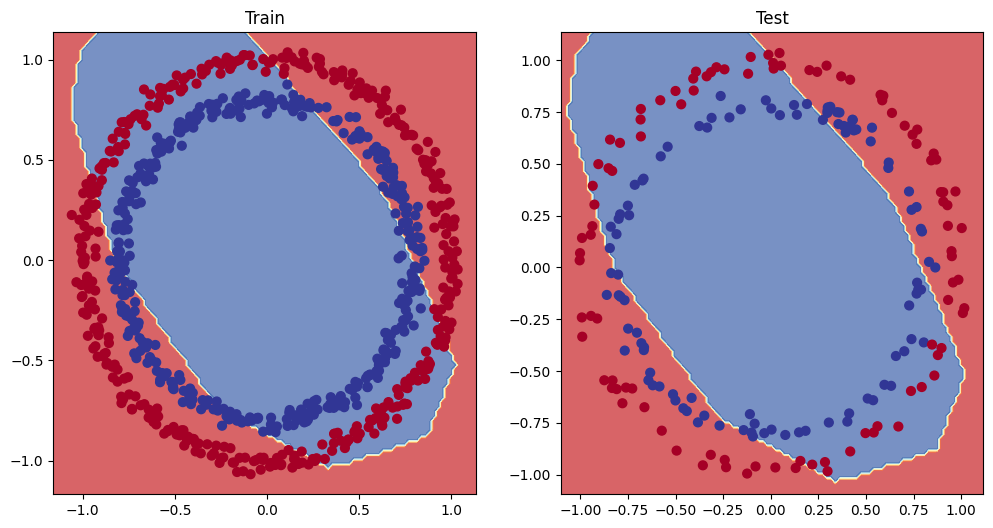

In [9]:
# Plot decision boundary 

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_3, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test)


### Replcating non_linear activation functions 

Neural networks, rather than us telling the model what to learn, we give it the tools to discover patterns in data and it tries to figure out the patterns on it's own.

And these tools are linear and non-linear functions.

In [10]:
# Create a tensor
A = torch.arange(-10, 10, 1, dtype = torch.float32)
A.dtype

torch.float32

In [11]:
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

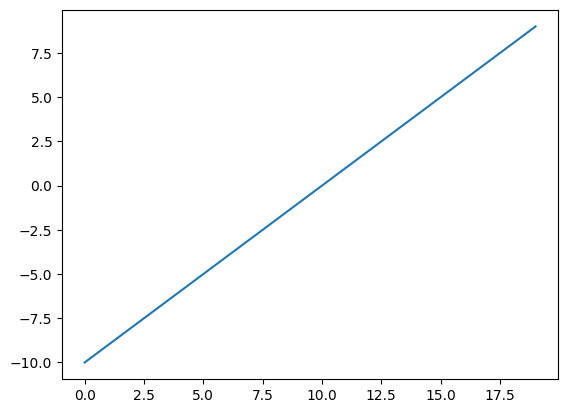

In [12]:
# Visualise the tensor 
plt.plot(A)

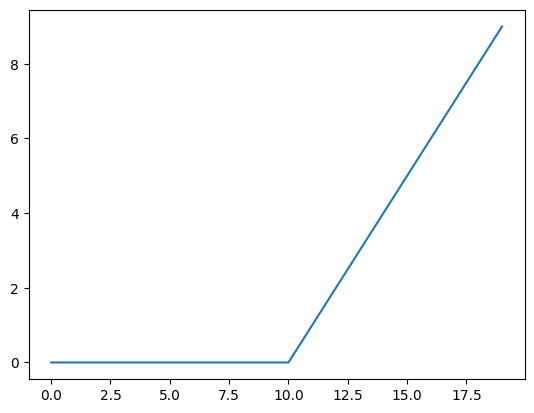

In [13]:
plt.plot(torch.relu(A))

In [14]:
def relu(x: torch.Tensor) -> torch.Tensor:
    return torch.maximum(torch.tensor(0), x) # inputs must be tensor

relu(A)


tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

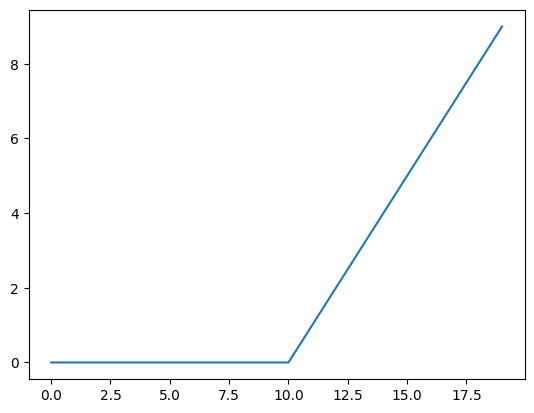

In [15]:
# Plot ReLU activation function

plt.plot(relu(A))

In [16]:
# Doing the same for sigmoid  

def sigmoid(x: torch.Tensor ) -> torch.Tensor: 
    return 1 / (1 + torch.exp(-x))

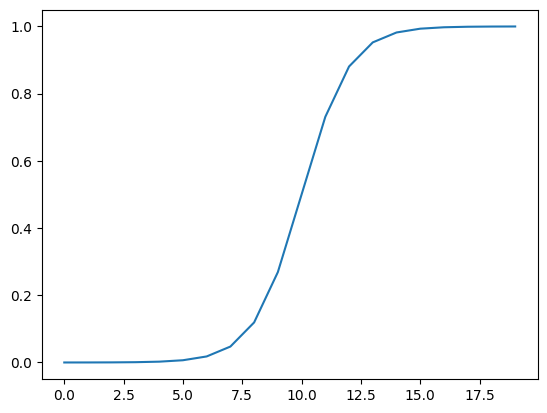

In [17]:
plt.plot(torch.sigmoid(A))

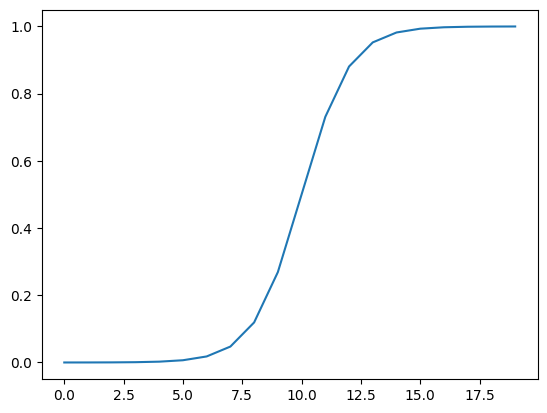

In [18]:
plt.plot(sigmoid(A))

### Putting it all together with a multi-class classification problem

* Binary classification  = one thing or another (cat vs dog, spam or not spam, fraud or not fraud)

* Multi-class classification = more than one thing or another (cat vs dog vs chicken)

### Creating a toy multi-class dataset 

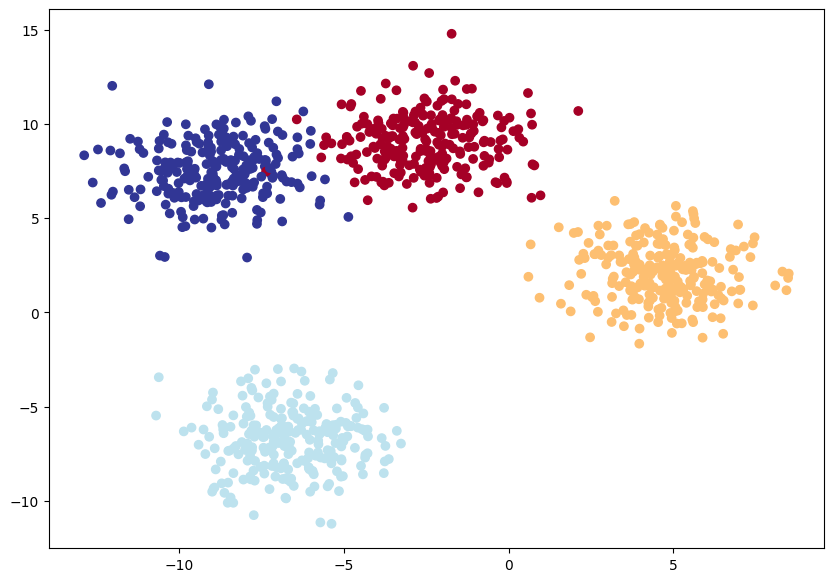

In [19]:
import torch 
import matplotlib.pyplot as plt 
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Set the number of hyperparameters for data creation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1. Create multi-class data
X_blob, y_blob = make_blobs(n_samples = 1000,
                             n_features = NUM_FEATURES,
                            centers = NUM_CLASSES,
                            cluster_std = 1.5, # give the clusters a little shake up
                            random_state=RANDOM_SEED)

# Turn data into tensors 
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

# Splt into train and test 
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
                                                                        y_blob,
                                                                        test_size = 0.2,
                                                                        random_state = RANDOM_SEED)

# plot data (visualize, visualize, visualize)
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu)


### Building My First Multi-class Classification Model. 

In [20]:
# Create Device agnostic codecy_fn

device =  "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [21]:
# Build a muilti-class classification model 

class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        """initialises multi-class classification model
        
        Args: 
        input_features (int): Nummber of input features to teh model
        output_features (int): Number of outputs features (number of output classes)
        hidden_units (int): Number of hiden units between layers, default 8

        Returns:

        Example:
        """
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features = input_features, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_features)
        )  

    def forward(self, x):
        return self.linear_layer_stack(x)
    

# Create an instane of BlobModel and send it to the target device
model_4 = BlobModel(input_features=2,
                    output_features=4,
                    hidden_units=8).to(device)
 

In [22]:
X_blob_train.shape,  y_blob_train[:5]

(torch.Size([800, 2]), tensor([1, 0, 2, 2, 0]))

### Creating a loss function and an optimiser for a multi-class classification model



In [23]:
loss_fn = nn.CrossEntropyLoss()
# optimizer 
optimizer = torch.optim.SGD(params = model_4.parameters(),
                            lr = 0.1) ### Learning rate remains an hyperparameter.



### Getting Prediction probabilities for a multi-class PyTorch Model 

in order to evaluate and train the model, we need to convert our model's outputs(logits) to prediction probabilities and then to prediction labels 

Logits (raw output of the model) --> pred probs (use torch.softmax)--> pred Labels (take the argmax of the prediction probabilities). 

In [24]:
model_4.eval()
with torch.inference_mode():
    y_logits = model_4(X_blob_test.to(device))

y_preds[:10]

tensor([1., 1., 0., 1., 1., 1., 0., 0., 0., 0.])

In [25]:
# Convert our logits output to prediction probabilities.

y_pred_probs = torch.softmax(y_logits, dim = 1)
print(y_logits[:5])
print(y_pred_probs[:5])


tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834]])
tensor([[0.3169, 0.3244, 0.1405, 0.2182],
        [0.3336, 0.1432, 0.2026, 0.3206],
        [0.3011, 0.1843, 0.2823, 0.2323],
        [0.3078, 0.2766, 0.1836, 0.2320],
        [0.3719, 0.1286, 0.1532, 0.3463]])


In [26]:
# convert our prediction probabilities to prediction labels.

y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds

tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 3, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 1, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 3, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 1, 0, 1])

In [27]:
y_blob_test

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0, 1, 2,
        2, 2, 3, 0, 1, 0, 3, 1, 1, 3, 1, 2, 1, 3, 0, 2, 0, 3, 3, 2, 0, 3, 1, 1,
        0, 3, 1, 0, 1, 1, 3, 2, 1, 1, 3, 2, 2, 0, 3, 2, 2, 0, 0, 3, 3, 0, 0, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 0, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 0, 3, 2, 0, 0, 3, 0, 2, 3, 1, 0, 3, 2, 1, 1, 0, 2, 2, 3, 0, 0, 1, 2,
        2, 3, 0, 1, 2, 0, 0, 0, 2, 3, 1, 2, 3, 2, 0, 3, 0, 0, 1, 1, 1, 0, 2, 2,
        2, 2, 0, 3, 3, 2, 2, 1, 3, 2, 0, 0, 3, 3, 2, 1, 2, 0, 3, 2, 0, 3, 2, 0,
        2, 2, 2, 0, 3, 1, 1, 1, 1, 1, 3, 1, 0, 2, 2, 1, 2, 2, 0, 1, 2, 2, 0, 0,
        1, 3, 2, 0, 3, 1, 2, 1])

### Create a training and testing loop for a multi-class classification model.



In [28]:
# Fit the multi-class model to the data
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set number of epochs
epochs  = 100

# Put data to the target device 
X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

# Loop through data
for epoch in range(epochs):
    ### Training 
    model_4.train()

    y_logits = model_4(X_blob_train)
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

    loss = loss_fn(y_logits, y_blob_train)
    acc = accuracy_fn(y_true=y_blob_train,
                      y_pred=y_pred)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    ### Testing 
    model_4.eval()
    with torch.inference_mode():
        test_logits = model_4(X_blob_test)
        test_preds = torch.softmax(test_logits, dim=1).argmax(dim=1)

        test_loss = loss_fn(test_logits, y_blob_test)
        test_acc = accuracy_fn(y_true = y_blob_test,
                               y_pred= test_preds)
        
    # Print out what's happening  
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.4f}, Acc: {acc:.2f}% | Test loss: {test_loss:.4f}, Test acc: {test_acc:.2f}%")


Epoch: 0 | Loss: 1.1588, Acc: 40.38% | Test loss: 1.0755, Test acc: 48.00%
Epoch: 10 | Loss: 0.6448, Acc: 96.75% | Test loss: 0.6607, Test acc: 97.50%
Epoch: 20 | Loss: 0.4254, Acc: 98.50% | Test loss: 0.4307, Test acc: 100.00%
Epoch: 30 | Loss: 0.2529, Acc: 99.12% | Test loss: 0.2451, Test acc: 99.50%
Epoch: 40 | Loss: 0.1123, Acc: 99.25% | Test loss: 0.1023, Test acc: 99.50%
Epoch: 50 | Loss: 0.0663, Acc: 99.25% | Test loss: 0.0585, Test acc: 99.50%
Epoch: 60 | Loss: 0.0507, Acc: 99.25% | Test loss: 0.0429, Test acc: 99.50%
Epoch: 70 | Loss: 0.0430, Acc: 99.25% | Test loss: 0.0349, Test acc: 99.50%
Epoch: 80 | Loss: 0.0384, Acc: 99.25% | Test loss: 0.0299, Test acc: 99.50%
Epoch: 90 | Loss: 0.0352, Acc: 99.25% | Test loss: 0.0266, Test acc: 99.50%


### Making and evaluating predictions with a PyTorch multi-class Model

In [29]:
# make predictions 
model_4.eval()
with torch.inference_mode():
    y_logits = model_4(X_blob_test)

# View the first 10 predictions 
y_logits[:10]

tensor([[-0.6249,  5.9860, -7.6323, -8.4470],
        [-2.1738, -6.3750, -3.7202,  3.1203],
        [-3.4102, -3.8958,  3.1567, -2.6119],
        [-1.1505,  4.1962, -3.8472, -4.8820],
        [ 3.7548, -1.3391, -9.1422, -6.9466],
        [-2.8211, -7.5767, -4.2944,  3.7944],
        [-3.0306, -3.3328,  2.7955, -2.1374],
        [ 3.3761, -4.0375, -6.8987, -3.5503],
        [-4.3620, -4.9904,  3.8123, -3.3814],
        [ 3.5012, -3.0281, -7.5401, -4.7064]])

In [30]:
# Go from logits  -> Prediction probabilities 
y_pred_probs = torch.softmax(y_logits, dim=1)
y_pred_probs[:10]


tensor([[1.3437e-03, 9.9865e-01, 1.2164e-06, 5.3854e-07],
        [4.9905e-03, 7.4740e-05, 1.0630e-03, 9.9387e-01],
        [1.3985e-03, 8.6060e-04, 9.9463e-01, 3.1073e-03],
        [4.7389e-03, 9.9483e-01, 3.1956e-04, 1.1353e-04],
        [9.9388e-01, 6.0966e-03, 2.4904e-06, 2.2378e-05],
        [1.3372e-03, 1.1504e-05, 3.0644e-04, 9.9834e-01],
        [2.9138e-03, 2.1537e-03, 9.8781e-01, 7.1181e-03],
        [9.9838e-01, 6.0198e-04, 3.4435e-05, 9.7989e-04],
        [2.8147e-04, 1.5016e-04, 9.9882e-01, 7.5044e-04],
        [9.9825e-01, 1.4575e-03, 1.5997e-05, 2.7210e-04]])

In [31]:
# Go from pred probs to pred labels 
y_preds = torch.argmax(y_pred_probs, dim = 1)
y_preds[:10]


tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])

In [32]:
y_blob_test

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0, 1, 2,
        2, 2, 3, 0, 1, 0, 3, 1, 1, 3, 1, 2, 1, 3, 0, 2, 0, 3, 3, 2, 0, 3, 1, 1,
        0, 3, 1, 0, 1, 1, 3, 2, 1, 1, 3, 2, 2, 0, 3, 2, 2, 0, 0, 3, 3, 0, 0, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 0, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 0, 3, 2, 0, 0, 3, 0, 2, 3, 1, 0, 3, 2, 1, 1, 0, 2, 2, 3, 0, 0, 1, 2,
        2, 3, 0, 1, 2, 0, 0, 0, 2, 3, 1, 2, 3, 2, 0, 3, 0, 0, 1, 1, 1, 0, 2, 2,
        2, 2, 0, 3, 3, 2, 2, 1, 3, 2, 0, 0, 3, 3, 2, 1, 2, 0, 3, 2, 0, 3, 2, 0,
        2, 2, 2, 0, 3, 1, 1, 1, 1, 1, 3, 1, 0, 2, 2, 1, 2, 2, 0, 1, 2, 2, 0, 0,
        1, 3, 2, 0, 3, 1, 2, 1])

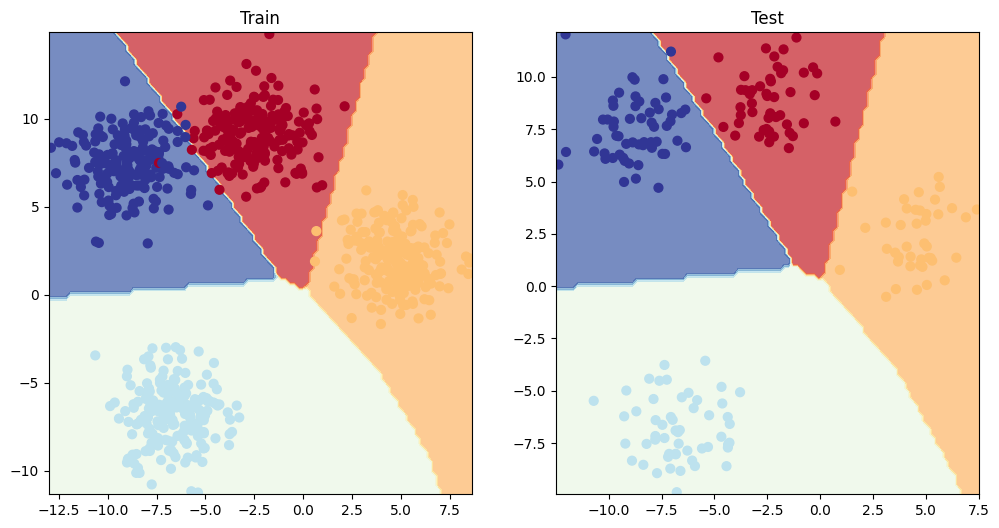

In [33]:
plt.figure(figsize = (12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)


### a few more classification metrics (to evaluate our classification metrics)

* Accuracy - out of 100 samples how many does our model get right `((tp + tn)/(tp + tn) + (fp + fn))`     **code** ---> `torchmetrics.Accuracy()` or `sklearn.metrics.accuracy_score()`
* Precision - ((tp)/(tp + fp))  torchmetrics.Precision or sklearn.metrics.precision_score()
* Recall - torchmetrics.Recall() or sklearn.metrics.recall_score
* F1 Score - torchmetrics.F1Score() or sklearn.metrics.f1_score()
* Confusion Matrix 
* Classification report 

#### TORCHMETRICS HAS A BETTER DOUMENTATION 


In [34]:
!pip install torchmetrics

ERROR: Could not find a version that satisfies the requirement torchmetrics (from versions: none)
ERROR: No matching distribution found for torchmetrics


In [35]:
from torchmetrics import Accuracy

# Setup metric
torchmetric_accuracy = Accuracy()

# Calculate accuracy
torchmetric_accuracy (y_preds, y_blob_test) 

ModuleNotFoundError: No module named 'torchmetrics'